🟢 Ускорение MPS (Metal) активировано.
Загружены данные из файла data/historical/ADBE.csv
Данные подготовлены. Всего точек: 2515
Генерация окон и вейвлет-процессинг...
Размер Train X: (2214, 30, 5)
Размер Test X: (221, 30, 5)
Начало обучения...
Epoch 5/50, Loss: 1.047318
Epoch 10/50, Loss: 0.965910
Epoch 15/50, Loss: 0.911485
Epoch 20/50, Loss: 0.864061
Epoch 25/50, Loss: 0.825450
Epoch 30/50, Loss: 0.731147
Epoch 35/50, Loss: 0.714748
Epoch 40/50, Loss: 0.607239
Epoch 45/50, Loss: 0.560225
Epoch 50/50, Loss: 0.506634
------------------------------
📊 RESULTS FOR ADBE
RMSE: 0.024956
MAE:  0.015695
Directional Accuracy (DA): 53.85%
Confusion Matrix (Up vs Down):
[[43 63]
 [39 76]]


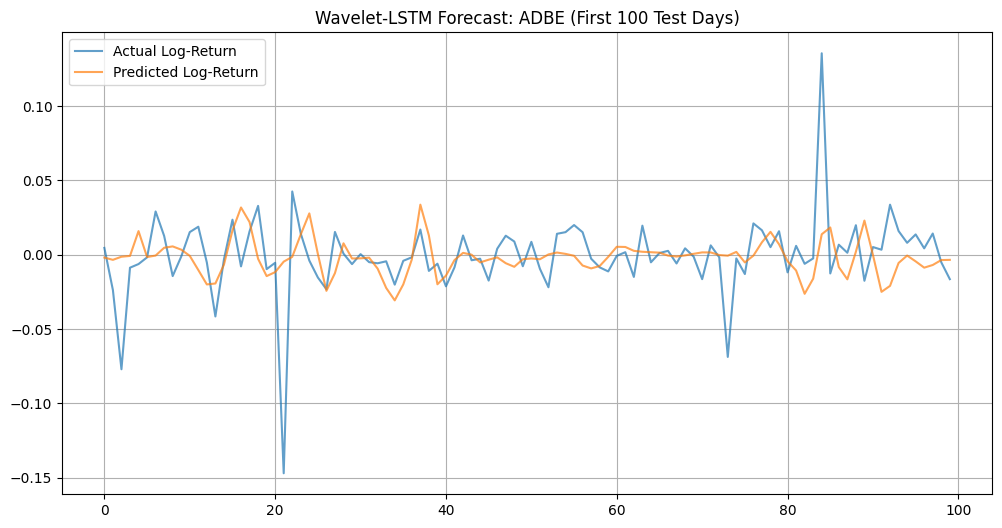

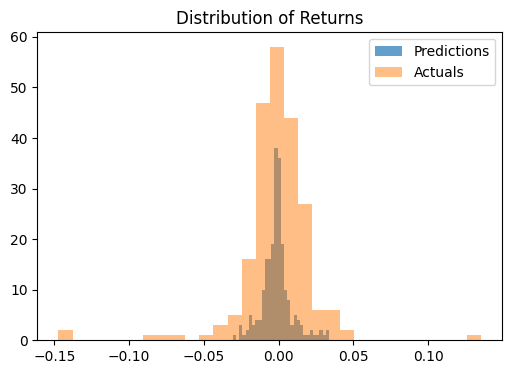

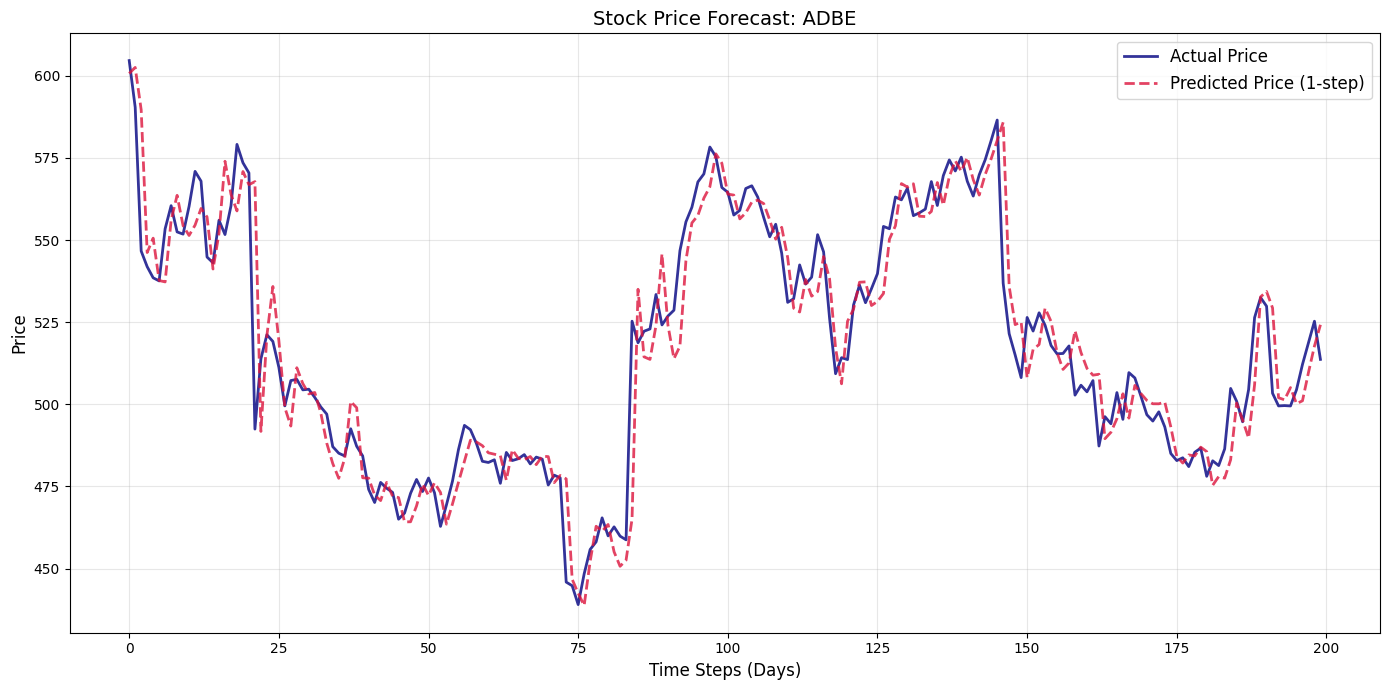

Price chart generated and saved.


In [50]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import pywt
import warnings
import os
# --- SYSTEM CONFIG ---
warnings.filterwarnings('ignore')


if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("🟢 Ускорение MPS (Metal) активировано.")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("🟢 Ускорение CUDA активировано.")
else:
    DEVICE = torch.device("cpu")
    print("🔴 Используется CPU.")

# --- CONFIG ---
TICKER = 'ADBE' # Тикер (для примера, данные будут фиктивные)
#
DATA_PATH = f'data/historical/{TICKER}.csv'

if os.path.exists(DATA_PATH):
    try:
        df = pd.read_csv(DATA_PATH)
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
        print(f"Загружены данные из файла {DATA_PATH}")
    except Exception as e:
        print(f"Ошибка при загрузке данных из файла: {e}")

else:
    print(f"Файл {DATA_PATH} не найден")



# Параметры модели
LOOKBACK = 30       # Длина окна (в днях)
PREDICT_STEP = 1    # Прогноз на 1 день
# Подберите дату разделения в зависимости от ваших данных
TRAIN_SPLIT_DATE = '2024-01-01'
BATCH_SIZE = 32
EPOCHS = 50
LR = 0.001

print(f"Данные подготовлены. Всего точек: {len(df)}")

# --- 1. FEATURE ENGINEERING ---
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def create_features(df):
    data = df.copy()

    # 1. Log-Return (Целевая переменная и фича)
    # r_t = ln(P_t / P_{t-1})
    data['Log_Ret'] = np.log(data['Close'] / data['Close'].shift(1))

    # 2. Volatility (Rolling Std Dev of returns)
    data['Volatility'] = data['Log_Ret'].rolling(window=20).std()

    # 3. Technical Indicators
    data['RSI'] = calculate_rsi(data['Close'])
    data['MA_20'] = data['Close'].rolling(window=20).mean()

    # Дистанция от MA (нормализованная)
    data['Dist_MA'] = (data['Close'] - data['MA_20']) / data['MA_20']

    # Удаляем NaN, появившиеся из-за лагов
    data.dropna(inplace=True)
    return data

df_features = create_features(df)

# --- 2. DATA PREPARATION (Strict No-Leakage) ---

# Разделение на Train и Test ДО масштабирования
train_data = df_features[df_features.index < TRAIN_SPLIT_DATE]
test_data = df_features[df_features.index >= TRAIN_SPLIT_DATE]

# Определяем фичи для входа (исключая дату и сырые цены, оставляем стационарные)
feature_cols = ['Log_Ret', 'Volatility', 'RSI', 'Dist_MA']
target_col = 'Log_Ret'

# Scaling (Fit только на Train!)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data[feature_cols])
test_scaled = scaler.transform(test_data[feature_cols])

# Конвертация обратно в DataFrame для удобства нарезки окон
train_df_scaled = pd.DataFrame(train_scaled, columns=feature_cols, index=train_data.index)
test_df_scaled = pd.DataFrame(test_scaled, columns=feature_cols, index=test_data.index)


# --- 3. WAVELET HELPER & DATASET ---
def apply_wavelet_smooth(window_data, wavelet='db4', level=1):
    coeffs = pywt.wavedec(window_data, wavelet, mode='periodization', level=level)
    coeffs_rec = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
    rec_signal = pywt.waverec(coeffs_rec, wavelet, mode='periodization')
    if len(rec_signal) > len(window_data):
        rec_signal = rec_signal[:len(window_data)]
    elif len(rec_signal) < len(window_data):
        rec_signal = np.pad(rec_signal, (0, len(window_data)-len(rec_signal)), 'edge')
    return rec_signal

def create_sequences(data_df, target_values, lookback):
    X, y = [], []
    values = data_df.values
    targets = target_values.values
    for i in range(len(values) - lookback):
        window = values[i : i + lookback]
        log_ret_window = window[:, 0]
        trend_component = apply_wavelet_smooth(log_ret_window)
        trend_component = trend_component.reshape(-1, 1)
        window_with_wavelet = np.hstack((window, trend_component))
        X.append(window_with_wavelet)
        y.append(targets[i + lookback])
    return np.array(X), np.array(y)

print("Генерация окон и вейвлет-процессинг...")
X_train, y_train = create_sequences(train_df_scaled, train_df_scaled[target_col], LOOKBACK)
X_test, y_test = create_sequences(test_df_scaled, test_df_scaled[target_col], LOOKBACK)

X_train_t = torch.FloatTensor(X_train).to(DEVICE)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
X_test_t = torch.FloatTensor(X_test).to(DEVICE)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(DEVICE)

print(f"Размер Train X: {X_train.shape}")
print(f"Размер Test X: {X_test.shape}")

# --- 4. MODEL ARCHITECTURE ---
class WaveletLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1, dropout=0.2):
        super(WaveletLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.activation = nn.Identity()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(DEVICE)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc(out)
        return out

INPUT_DIM = X_train.shape[2]
HIDDEN_DIM = 64
LAYERS = 2

model = WaveletLSTM(INPUT_DIM, HIDDEN_DIM, LAYERS).to(DEVICE)
criterion = nn.MSELoss() # Можно попробовать nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# --- 5. TRAINING LOOP ---
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
loss_history = []

print("Начало обучения...")
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.6f}")

# --- 6. EVALUATION ---
model.eval()
with torch.no_grad():
    predictions = model(X_test_t).cpu().numpy()
    actuals = y_test_t.cpu().numpy()

dummy_pred = np.zeros((len(predictions), len(feature_cols)))
dummy_act = np.zeros((len(actuals), len(feature_cols)))

dummy_pred[:, 0] = predictions.flatten()
dummy_act[:, 0] = actuals.flatten()

pred_rescaled = scaler.inverse_transform(dummy_pred)[:, 0]
act_rescaled = scaler.inverse_transform(dummy_act)[:, 0]

rmse = np.sqrt(mean_squared_error(act_rescaled, pred_rescaled))
mae = mean_absolute_error(act_rescaled, pred_rescaled)

pred_sign = np.sign(pred_rescaled)
act_sign = np.sign(act_rescaled)
da = accuracy_score(act_sign, pred_sign)

print("-" * 30)
print(f"📊 RESULTS FOR {TICKER}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"Directional Accuracy (DA): {da*100:.2f}%")

cm = confusion_matrix(act_sign, pred_sign, labels=[1, -1])
print("Confusion Matrix (Up vs Down):")
print(cm)

# --- 7. VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.plot(act_rescaled[:100], label='Actual Log-Return', alpha=0.7)
plt.plot(pred_rescaled[:100], label='Predicted Log-Return', alpha=0.7)
plt.title(f'Wavelet-LSTM Forecast: {TICKER} (First 100 Test Days)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(pred_rescaled, bins=30, alpha=0.7, label='Predictions')
plt.hist(act_rescaled, bins=30, alpha=0.5, label='Actuals')
plt.title('Distribution of Returns')
plt.legend()
plt.show()

# --- 8. PRICE RECONSTRUCTION & PLOTTING ---
# Get actual Close prices from the test set
# test_data.index corresponds to dates in the test set
test_close_prices = df['Close'][test_data.index].values

# We need to align prices with predictions.
# The model predicts for time 't' using window ending at 't-1'.
# The first prediction corresponds to index = LOOKBACK in the test set.
actual_prices = test_close_prices[LOOKBACK:]
prev_prices = test_close_prices[LOOKBACK-1 : -1]  # Prices at t-1

# Reconstruct predicted prices: Price_t = Price_{t-1} * exp(Log_Return_t)
pred_prices = prev_prices * np.exp(pred_rescaled)

# Visualization of Price
plt.figure(figsize=(14, 7))

# Plot a subset (e.g., first 200 points) for better visibility, or remove [:200] for full range
plot_limit = 200

plt.plot(actual_prices[:plot_limit], label='Actual Price', color='navy', alpha=0.8, linewidth=2)
plt.plot(pred_prices[:plot_limit], label='Predicted Price (1-step)', color='crimson', alpha=0.8, linestyle='--', linewidth=2)

plt.title(f'Stock Price Forecast: {TICKER}', fontsize=14)
plt.xlabel('Time Steps (Days)', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{TICKER}_price_chart.png')
plt.show()

print("Price chart generated and saved.")

## Сверху WAVELET+LSTM

# ARIMA+LSTM

Device: mps
Train size: 2263, Test size: 251
Обучение ARIMA...
Обучение LSTM на ошибках ARIMA...
Epoch 10/30, Residual Loss: 0.204654
Epoch 20/30, Residual Loss: 0.926467
Epoch 30/30, Residual Loss: 0.369111
------------------------------
📊 HYBRID ARIMA+LSTM RESULTS (ADBE)
RMSE: 0.024559
MAE:  0.015145
Directional Accuracy (DA): 53.94%
Confusion Matrix (Up vs Down):
[[45 70]
 [41 85]]


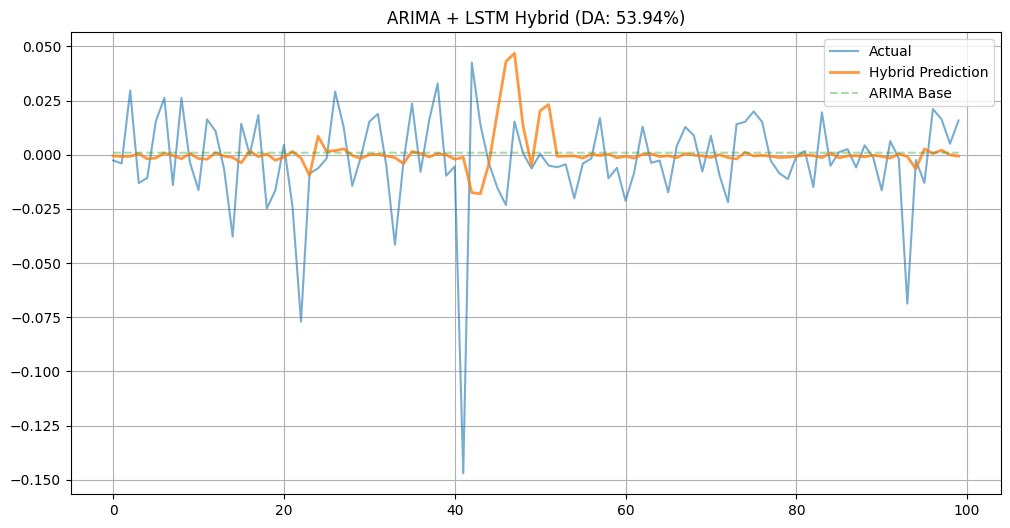

ValueError: operands could not be broadcast together with shapes (241,) (491,) 

In [41]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, accuracy_score
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')

# ==========================================
# ⚙️ НАСТРОЙКИ (Простые переменные)
# ==========================================
TICKER = 'ADBE'
DATA_PATH = f'data/historical/{TICKER}.csv'

# Дата разделения на обучение и тест
TRAIN_SPLIT_DATE = '2024-01-01'

# Параметры окна
LOOKBACK = 10       # Окно для LSTM (на остатках)

# Параметры ARIMA (p,d,q)
# d=0, так как мы прогнозируем доходность (Log Return), она уже стационарна
ARIMA_ORDER = (5, 0, 1)

# Параметры LSTM
LSTM_HIDDEN_DIM = 64
LSTM_LAYERS = 2
DROPOUT = 0.2
BATCH_SIZE = 32
EPOCHS = 30         # Для остатков обычно нужно меньше эпох
LR = 0.001

# Устройство
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")

# ==========================================
# 1. ПОДГОТОВКА ДАННЫХ
# ==========================================
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

# Считаем Log Returns
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

# Разделение на Train и Test (до скейлинга)
train_df = df[df.index < TRAIN_SPLIT_DATE]
test_df = df[df.index >= TRAIN_SPLIT_DATE]

# Берем только целевую серию
train_series = train_df['Log_Ret'].values
test_series = test_df['Log_Ret'].values

print(f"Train size: {len(train_series)}, Test size: {len(test_series)}")

# ==========================================
# 2. ЭТАП ARIMA (Линейная модель)
# ==========================================
print("Обучение ARIMA...")

# Обучаем на Train
arima_model = ARIMA(train_series, order=ARIMA_ORDER)
arima_fit = arima_model.fit()

# Получаем предсказания (линейная база)
train_arima_pred = arima_fit.fittedvalues
# Прогноз на длину теста (в реальной торговле нужен rolling forecast, тут упрощено для скорости)
test_arima_pred = arima_fit.forecast(steps=len(test_series))

# Считаем ОСТАТКИ (Residuals) - то, что ARIMA не смогла угадать
train_residuals = train_series - train_arima_pred
test_residuals = test_series - test_arima_pred

# ==========================================
# 3. ПОДГОТОВКА ОСТАТКОВ ДЛЯ LSTM
# ==========================================
# Скейлинг остатков (важно для нейросети)
scaler_res = StandardScaler()
# Решейп для скейлера (-1, 1)
train_res_scaled = scaler_res.fit_transform(train_residuals.reshape(-1, 1))
test_res_scaled = scaler_res.transform(test_residuals.reshape(-1, 1))

# Функция создания окон
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_res_scaled, LOOKBACK)
X_test, y_test = create_sequences(test_res_scaled, LOOKBACK)

# В тензоры
X_train_t = torch.FloatTensor(X_train).to(DEVICE)
y_train_t = torch.FloatTensor(y_train).to(DEVICE)
X_test_t = torch.FloatTensor(X_test).to(DEVICE)
y_test_t = torch.FloatTensor(y_test).to(DEVICE)

# ==========================================
# 4. МОДЕЛЬ LSTM (Для остатков)
# ==========================================
class ResidualLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super(ResidualLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=DROPOUT)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, lookback, features=1)
        out, _ = self.lstm(x)
        out = out[:, -1, :] # Последний шаг
        out = self.fc(out)
        return out

model = ResidualLSTM(input_size=1, hidden_size=LSTM_HIDDEN_DIM, num_layers=LSTM_LAYERS).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ==========================================
# 5. ОБУЧЕНИЕ LSTM
# ==========================================
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

print("Обучение LSTM на ошибках ARIMA...")
model.train()
for epoch in range(EPOCHS):
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        pred = model(X_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Residual Loss: {loss.item():.6f}")

# ==========================================
# 6. СБОРКА РЕЗУЛЬТАТОВ
# ==========================================
model.eval()
with torch.no_grad():
    # Предсказываем остаток на тесте
    lstm_res_pred_scaled = model(X_test_t).cpu().numpy()

# Возвращаем масштаб остаткам
lstm_res_pred = scaler_res.inverse_transform(lstm_res_pred_scaled).flatten()

# Выравниваем длины массивов
# LSTM съедает первые LOOKBACK значений, поэтому обрезаем ARIMA и Факт
arima_part = test_arima_pred[LOOKBACK:]
actual_part = test_series[LOOKBACK:]

# ГЛАВНАЯ ФОРМУЛА: Прогноз = Линейная часть (ARIMA) + Нелинейная часть (LSTM)
final_pred = arima_part + lstm_res_pred

# ==========================================
# 7. МЕТРИКИ И DA
# ==========================================
rmse = np.sqrt(mean_squared_error(actual_part, final_pred))
mae = mean_absolute_error(actual_part, final_pred)

# Расчет Directional Accuracy
pred_sign = np.sign(final_pred)
act_sign = np.sign(actual_part)
da = accuracy_score(act_sign, pred_sign)

print("-" * 30)
print(f"📊 HYBRID ARIMA+LSTM RESULTS ({TICKER})")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"Directional Accuracy (DA): {da*100:.2f}%")

cm = confusion_matrix(act_sign, pred_sign, labels=[1, -1])
print("Confusion Matrix (Up vs Down):")
print(cm)

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(actual_part[:100], label='Actual', alpha=0.6)
plt.plot(final_pred[:100], label='Hybrid Prediction', alpha=0.8, linewidth=2)
plt.plot(arima_part[:100], label='ARIMA Base', alpha=0.4, linestyle='--')
plt.title(f'ARIMA + LSTM Hybrid (DA: {da*100:.2f}%)')
plt.legend()
plt.grid(True)
plt.show()

🚀 Device: mps
✅ Данные загружены: 2515 строк
Размер входа (Batch, Lookback, Features): torch.Size([2224, 20, 4])
Запуск обучения гибридной модели...
Epoch 10/50 | Loss: 0.939274
Epoch 20/50 | Loss: 0.756471
Epoch 30/50 | Loss: 0.536631
Epoch 40/50 | Loss: 0.368301
Epoch 50/50 | Loss: 0.282693
------------------------------
📊 CNN-LSTM RESULTS (ADBE)
RMSE (Returns): 0.026542
MAE (Returns):  0.016753
Directional Accuracy (DA): 57.14%


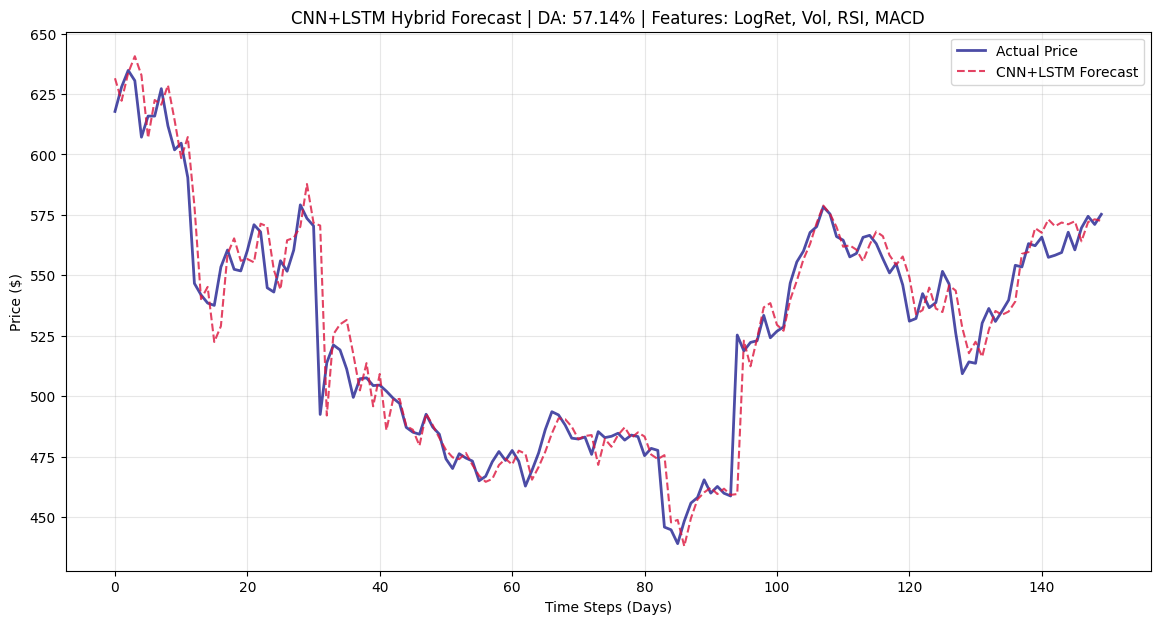

In [49]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import warnings
import os

# --- SYSTEM SETTINGS ---
warnings.filterwarnings('ignore')

# ==========================================
# ⚙️ НАСТРОЙКИ (ВАРЬИРУЙТЕ ЭТИ ЗНАЧЕНИЯ)
# ==========================================
TICKER = 'ADBE'
DATA_PATH = f'data/historical/{TICKER}.csv'
TRAIN_SPLIT_DATE = '2024-01-01'

# Данные
LOOKBACK = 20          # Важно: CNN нужно достаточно большое окно (30-90)

# Параметры CNN
CONV_FILTERS = 64      # Сколько фильтров (паттернов) искать
KERNEL_SIZE = 3        # Размер "взгляда" свертки

# Параметры LSTM
LSTM_HIDDEN_DIM = 128  # Мощность LSTM
LSTM_LAYERS = 2
DROPOUT = 0.3          # Борьба с переобучением

# Обучение
BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0005            # Чуть меньше для стабильности гибрида

# Устройство
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"🚀 Device: {DEVICE}")

# ==========================================
# 1. ЗАГРУЗКА ДАННЫХ (СТРОГО ИЗ ФАЙЛА)
# ==========================================
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    print(f"✅ Данные загружены: {len(df)} строк")
else:
    raise FileNotFoundError(f"❌ Файл {DATA_PATH} не найден! Генерация запрещена.")

# ==========================================
# 2. ПРОДВИНУТЫЙ FEATURE ENGINEERING
# ==========================================
# Для CNN полезно иметь "текстуру" рынка (индикаторы)
data = df.copy()

# 1. Цель (Log Returns) - стационарный ряд
data['Log_Ret'] = np.log(data['Close'] / data['Close'].shift(1))

# 2. Volatility (Rolling Std)
data['Volatility'] = data['Log_Ret'].rolling(window=20).std()

# 3. RSI
delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

# 4. MACD (Трендовый индикатор)
ema12 = data['Close'].ewm(span=12, adjust=False).mean()
ema26 = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD'] = ema12 - ema26

# Удаляем NaN от индикаторов
data.dropna(inplace=True)

# Выбираем фичи
feature_cols = ['Log_Ret', 'Volatility', 'RSI', 'MACD']
target_col = 'Log_Ret'

# ==========================================
# 3. ПОДГОТОВКА ТЕНЗОРОВ
# ==========================================
# Сплит по дате
train_data = data[data.index < TRAIN_SPLIT_DATE]
test_data = data[data.index >= TRAIN_SPLIT_DATE]

# Скейлинг
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data[feature_cols])
test_scaled = scaler.transform(test_data[feature_cols])

# Функция окна
def create_sequences(data, target_col_idx, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        # Окно фичей
        X.append(data[i : i + lookback])
        # Таргет (Log_Ret) - следующий шаг
        y.append(data[i + lookback, target_col_idx])
    return np.array(X), np.array(y)

target_idx = feature_cols.index(target_col)
X_train, y_train = create_sequences(train_scaled, target_idx, LOOKBACK)
X_test, y_test = create_sequences(test_scaled, target_idx, LOOKBACK)

# В PyTorch тензоры
X_train_t = torch.FloatTensor(X_train).to(DEVICE)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
X_test_t = torch.FloatTensor(X_test).to(DEVICE)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(DEVICE)

print(f"Размер входа (Batch, Lookback, Features): {X_train_t.shape}")

# ==========================================
# 4. АРХИТЕКТУРА CNN + LSTM
# ==========================================
class CNNLSTM(nn.Module):
    def __init__(self, num_features, hidden_dim, lstm_layers, conv_filters, kernel_size, dropout):
        super(CNNLSTM, self).__init__()

        # --- 1. CNN BLOCK (Feature Extraction) ---
        # Вход Conv1d ждет (Batch, Channels/Features, Length/Time)
        # Поэтому в forward мы будем менять оси местами
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=conv_filters, kernel_size=kernel_size, padding=1)
        self.bn1 = nn.BatchNorm1d(conv_filters)
        self. relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2) # Сжимаем временной ряд в 2 раза

        # --- 2. LSTM BLOCK (Temporal Pattern) ---
        # LSTM ждет (Batch, Length, Features)
        self.lstm = nn.LSTM(
            input_size=conv_filters,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout
        )

        # --- 3. HEAD ---
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: [Batch, Lookback, Features]

        # 1. Подготовка для CNN: пермутация осей -> [Batch, Features, Lookback]
        x = x.permute(0, 2, 1)

        # 2. CNN проход
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x) # Сокращаем длину последовательности вдвое

        # 3. Подготовка для LSTM: пермутация обратно -> [Batch, New_Length, Filters]
        x = x.permute(0, 2, 1)

        # 4. LSTM проход
        out, _ = self.lstm(x)

        # Берем последнее состояние
        out = out[:, -1, :]

        # 5. Финал
        out = self.fc(out)
        return out

model = CNNLSTM(
    num_features=len(feature_cols),
    hidden_dim=LSTM_HIDDEN_DIM,
    lstm_layers=LSTM_LAYERS,
    conv_filters=CONV_FILTERS,
    kernel_size=KERNEL_SIZE,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ==========================================
# 5. ОБУЧЕНИЕ
# ==========================================
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

print("Запуск обучения гибридной модели...")
model.train()
loss_history = []

for epoch in range(EPOCHS):
    epoch_loss = 0
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        pred = model(X_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

# ==========================================
# 6. ОЦЕНКА И РЕКОНСТРУКЦИЯ ЦЕНЫ
# ==========================================
model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).cpu().numpy()
    actual_scaled = y_test_t.cpu().numpy()

# Обратное масштабирование (хитрый трюк для 4 фичей)
# Создаем пустышки той же формы, что ждет скейлер
dummy_pred = np.zeros((len(pred_scaled), len(feature_cols)))
dummy_act = np.zeros((len(actual_scaled), len(feature_cols)))

# Записываем предсказания в колонку Log_Ret (индекс 0)
dummy_pred[:, 0] = pred_scaled.flatten()
dummy_act[:, 0] = actual_scaled.flatten()

# Инвертируем
pred_ret = scaler.inverse_transform(dummy_pred)[:, 0]
act_ret = scaler.inverse_transform(dummy_act)[:, 0]

# --- Метрики ---
rmse = np.sqrt(mean_squared_error(act_ret, pred_ret))
mae = mean_absolute_error(act_ret, pred_ret)

# Directional Accuracy
pred_sign = np.sign(pred_ret)
act_sign = np.sign(act_ret)
da = accuracy_score(act_sign, pred_sign)

print("-" * 30)
print(f"📊 CNN-LSTM RESULTS ({TICKER})")
print(f"RMSE (Returns): {rmse:.6f}")
print(f"MAE (Returns):  {mae:.6f}")
print(f"Directional Accuracy (DA): {da*100:.2f}%")

# --- Реконструкция Цены (Корректный метод) ---
# Берем индексы, соответствующие предсказаниям
test_data_indices = test_data.index[LOOKBACK:]

# Факт: Цена Close на эти даты
actual_price = test_data['Close'][LOOKBACK:].values

# Цена "Вчера" для предсказания "Сегодня"
# shift(1) берет цену предыдущего дня. loc фильтрует по датам прогноза.
prev_price = test_data['Close'].shift(1).loc[test_data_indices].values

# Формула: Price_t = Price_{t-1} * exp(Log_Ret_t)
pred_price = prev_price * np.exp(pred_ret)

# ==========================================
# 7. ВИЗУАЛИЗАЦИЯ
# ==========================================
plt.figure(figsize=(14, 7))
limit = 150 # Рисуем первые 150 дней для детальности

plt.plot(actual_price[:limit], label='Actual Price', color='navy', alpha=0.7, linewidth=2)
plt.plot(pred_price[:limit], label='CNN+LSTM Forecast', color='crimson', alpha=0.8, linestyle='--')

plt.title(f"CNN+LSTM Hybrid Forecast | DA: {da*100:.2f}% | Features: LogRet, Vol, RSI, MACD")
plt.xlabel("Time Steps (Days)")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{TICKER}_CNNLSTM_chart.png')
plt.show()




⏳ Завантаження data/historical/ADBE.csv...
📊 Train size: 2004 | Test size: 501
🚀 Старт тренування...
Epoch 5 | Loss: 0.997791
Epoch 10 | Loss: 0.936473
Epoch 15 | Loss: 0.931246
Epoch 20 | Loss: 0.881604
Epoch 25 | Loss: 0.847403
Epoch 30 | Loss: 0.819939


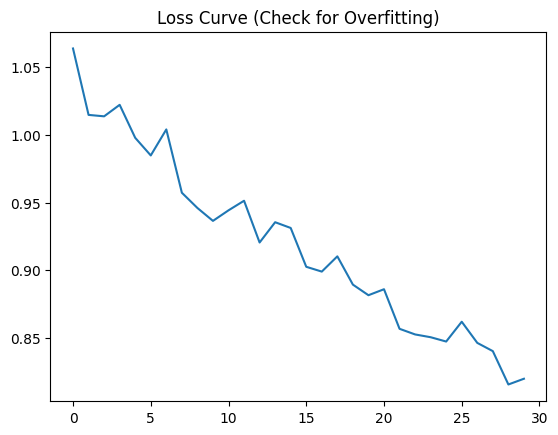

🔮 Генерація гібридного прогнозу...


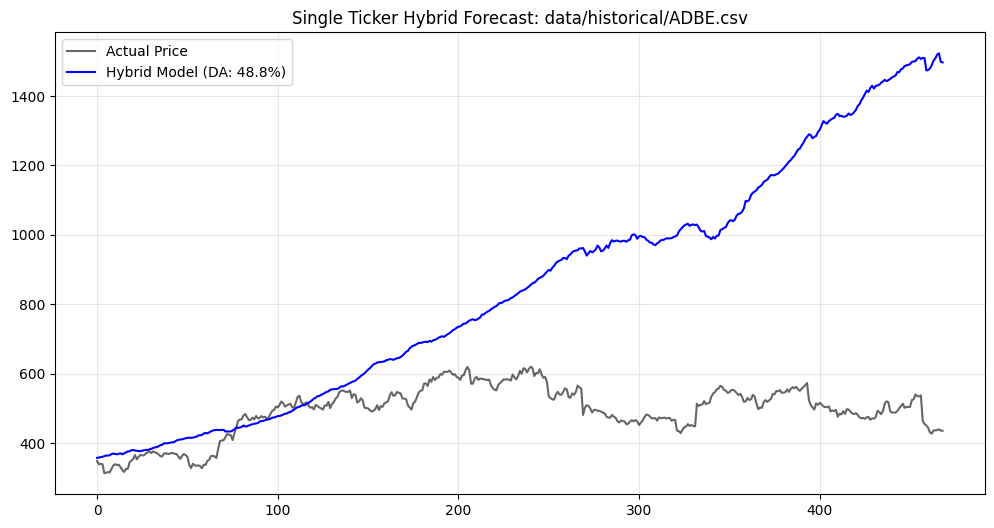

In [59]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ НАЛАШТУВАННЯ (Один Тікер)
# ==========================================
FILE_PATH = 'data/historical/ADBE.csv'  # 👈 Твій файл тут
LOOKBACK = 32       # Менше вікно, бо даних мало
PRED_LEN = 1
BATCH_SIZE = 32     # Менший батч
EPOCHS = 30         # Більше епох, бо датасет маленький
LR = 0.0005
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. TINY PATCH TST (Адаптовано під малі дані)
# ==========================================
class TinyPatchTST(nn.Module):
    def __init__(self, n_input, n_pred, patch_len=4, stride=4):
        super().__init__()
        # Зменшуємо параметри, щоб не було оверфіту
        d_model = 64        # Було 128
        n_heads = 2         # Було 4
        n_layers = 1        # Було 2 або 3
        dropout = 0.3       # Високий дропаут!

        self.n_input = n_input
        self.patch_len = patch_len
        self.stride = stride
        self.num_patches = (n_input - patch_len) // stride + 1

        # Input: 2 features (LogRet, Vol)
        self.projection = nn.Linear(2 * patch_len, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches, d_model))

        encoder_layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=128, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, n_layers)

        self.flatten = nn.Flatten()
        self.head = nn.Linear(self.num_patches * d_model, n_pred)

    def forward(self, x):
        # x: [Batch, Lookback, 2]
        batch_size = x.shape[0]
        # Спрощений unfold
        patches = x.unfold(1, self.patch_len, self.stride)
        patches = patches.reshape(batch_size, self.num_patches, -1)

        x_emb = self.projection(patches) + self.pos_embedding
        z = self.encoder(x_emb)
        return self.head(self.flatten(z))

# ==========================================
# 2. ПІДГОТОВКА ДАНИХ (Single Ticker)
# ==========================================
print(f"⏳ Завантаження {FILE_PATH}...")
df = pd.read_csv(FILE_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Feature Engineering
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df['Vol'] = df['Log_Ret'].rolling(10).std()
df.dropna(inplace=True)

# Split Train/Test
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print(f"📊 Train size: {len(train_df)} | Test size: {len(test_df)}")

# Scaler (Fit on Train ONLY)
scaler = StandardScaler()
train_vals = train_df[['Log_Ret', 'Vol']].values
test_vals = test_df[['Log_Ret', 'Vol']].values

scaler.fit(train_vals) # 👈 Важливо!
train_scaled = scaler.transform(train_vals)
test_scaled = scaler.transform(test_vals)

# Dataset Class
class SingleTickerDataset(Dataset):
    def __init__(self, data, lookback):
        self.data = data
        self.lookback = lookback

    def __len__(self):
        return len(self.data) - self.lookback

    def __getitem__(self, idx):
        # X: вікно, y: наступне значення (тільки Log_Ret -> індекс 0)
        x = self.data[idx : idx+self.lookback]
        y = self.data[idx+self.lookback, 0]
        return torch.FloatTensor(x), torch.FloatTensor([y])

train_ds = SingleTickerDataset(train_scaled, LOOKBACK)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

# ==========================================
# 3. ТРЕНУВАННЯ
# ==========================================
model = TinyPatchTST(n_input=LOOKBACK, n_pred=PRED_LEN).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR) # Adam звичайний краще для малих даних
criterion = nn.MSELoss()

loss_history = []

print("🚀 Старт тренування...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.6f}")

plt.plot(loss_history)
plt.title("Loss Curve (Check for Overfitting)")
plt.show()

# ==========================================
# 4. HYBRID PREDICTION LOOP
# ==========================================
print("🔮 Генерація гібридного прогнозу...")

model.eval()
preds_hybrid = []
actuals = []

# Історія для ARIMA (починаємо з тренувальної)
history = list(train_df['Log_Ret'].values)

# Проходимо по тесту
# Важливо: беремо scaled_window з test_scaled для моделі
for i in range(len(test_scaled) - LOOKBACK):

    # --- 1. PatchTST (Neural) ---
    # Вікно з тестових даних
    window = test_scaled[i : i+LOOKBACK]
    window_tensor = torch.FloatTensor(window).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_nn_scaled = model(window_tensor).cpu().item()

    # Inverse transform (hacky way for single value)
    dummy = np.zeros((1, 2))
    dummy[0, 0] = pred_nn_scaled
    pred_nn = scaler.inverse_transform(dummy)[0, 0]

    # --- 2. ARIMA (Linear) ---
    # Тренуємо на історії (rolling window 50-100 точок для швидкості)
    # Order (2,0,1) або (1,0,0) - прості моделі
    try:
        arima_model = ARIMA(history[-60:], order=(2,0,1)).fit()
        pred_arima = arima_model.forecast(steps=1)[0]
    except:
        pred_arima = 0.0

    # --- 3. HYBRID WEIGHTING ---
    # На одному тікері ARIMA часто надійніша, тому даємо їй вагу
    # Але якщо є впевненість у TST, можна 0.5/0.5
    final_pred = 0.4 * pred_arima + 0.6 * pred_nn

    preds_hybrid.append(final_pred)

    # Реальне значення (для метрик і додавання в історію ARIMA)
    # Важливо брати не scaled, а raw значення з test_vals
    real_val = test_vals[i+LOOKBACK, 0]
    actuals.append(real_val)

    # Оновлюємо історію для ARIMA
    history.append(real_val)

# ==========================================
# 5. ВІЗУАЛІЗАЦІЯ ЦІНИ
# ==========================================
# Відновлюємо ціну з Log Returns
start_price = test_df.iloc[LOOKBACK]['Close']

# Cumulative returns -> Price path
price_actual = start_price * np.exp(np.cumsum(actuals))
price_pred = start_price * np.exp(np.cumsum(preds_hybrid))

# Метрика DA (Directional Accuracy)
da = np.mean(np.sign(actuals) == np.sign(preds_hybrid)) * 100

plt.figure(figsize=(12, 6))
plt.plot(price_actual, label='Actual Price', color='black', alpha=0.6)
plt.plot(price_pred, label=f'Hybrid Model (DA: {da:.1f}%)', color='blue', linewidth=1.5)
plt.title(f"Single Ticker Hybrid Forecast: {FILE_PATH}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()